## Многофакторная линейная регрессия

Источник данных: https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset

Набор данных о здоровье сна и образе жизни включает такие данные, как пол, возраст, профессия, продолжительность сна, качество сна, уровень физической активности, уровень стресса, категория ИМТ, артериальное давление, частота сердечных сокращений, количество шагов в день, а также наличие или отсутствие нарушений сна.

<details>
<summary>Описание признаков</summary>

| Признак | Описание |
|---------|----------|
| Person ID | An identifier for each individual |
| Gender | The gender of the person (Male/Female) |
| Age | The age of the person in years |
| Occupation | The occupation or profession of the person |
| Sleep Duration (hours) | The number of hours the person sleeps per day |
| Quality of Sleep (scale: 1-10) | A subjective rating of the quality of sleep, ranging from 1 to 10 |
| Physical Activity Level (minutes/day) | The number of minutes the person engages in physical activity daily |
| Stress Level (scale: 1-10) | A subjective rating of the stress level experienced by the person, ranging from 1 to 10 |
| BMI Category | The BMI category of the person (e.g., Underweight, Normal, Overweight) |
| Blood Pressure | The blood pressure measurement of the person, indicated as systolic pressure over diastolic pressure |
| Heart Rate (bpm) | The resting heart rate of the person in beats per minute |
| Daily Steps | The number of steps the person takes per day |
| Sleep Disorder | The presence or absence of a sleep disorder in the person (None, Insomnia, Sleep Apnea) |

</details>

#### Цель: изучить зависимость продолжительности сна от субъективных и объективных показателей состояния здоровья человека.

#### Задача: построить многофакторную регрессионную модель, отражающую зависимость продолжительности сна от нескольких других показателей (пол, возраст, давление, чсс и т.д.).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

Исходные данные

In [2]:
data = pd.read_csv("data/sleep.csv")
data.sample(5)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
34,35,Male,31,Doctor,7.7,7,75,6,Normal,120/80,70,8000,NaN
239,240,Male,44,Salesperson,6.4,6,45,7,Overweight,130/85,72,6000,Insomnia
343,344,Female,57,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,NaN
229,230,Male,44,Salesperson,6.3,6,45,7,Overweight,130/85,72,6000,Insomnia
330,331,Female,53,Engineer,8.5,9,30,3,Normal,125/80,65,5000,NaN


Некоторые статистики по признакам:

In [3]:
data.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [4]:
data.describe(include=["O"])

C:\Users\temic\AppData\Local\Temp\ipykernel_15820\1126752233.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include=["O"])


,Gender,Occupation,BMI Category,Blood Pressure,Sleep Disorder
count,374,374,374,374,155
unique,2,11,4,25,2
top,Male,Nurse,Normal,130/85,Sleep Apnea
freq,189,73,195,99,78


Пропущенные значения:

In [5]:
data.isna().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

Заменим пропущенные значения признака "Нарушение сна" строкой "No"

In [6]:
data["Sleep Disorder"] = data["Sleep Disorder"].fillna("No")

ID человека в датасете, очевидно, совсем не влияет на длительность сна, поэтому этот признак не будет использован.

In [7]:
data = data.drop(columns=["Person ID"])

### Приведение всех данных к стандартному виду

Категориальные признаки закодируем, признак "Blood Pressure" разделим на два признака -- верхнее и нижнее давление

In [8]:
def split_blood_pressure(df):
    df_copy = df.copy()

    split = df_copy["Blood Pressure"].str.split('/', expand=True)
    df_copy["Systolic"] = pd.to_numeric(split[0], errors="coerce")
    df_copy["Diastolic"] = pd.to_numeric(split[1], errors="coerce")
    df_copy = df_copy.drop('Blood Pressure', axis=1)
    
    return df_copy

In [9]:
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler, OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer

numeric_features = data.select_dtypes(include="number").columns.tolist()
numeric_features.remove("Sleep Duration")
numeric_features.extend(["Systolic", "Diastolic"])
cat_features = data.select_dtypes(include="object").columns.drop("Blood Pressure").tolist()

pressure_tf = FunctionTransformer(split_blood_pressure)

pipeline = make_pipeline(
    pressure_tf,
    make_column_transformer(
        (MinMaxScaler(), numeric_features),
        (OneHotEncoder(sparse_output=False, handle_unknown="ignore"), cat_features),
        verbose_feature_names_out=False,
        remainder="passthrough"
    )
)
data_transformed = pipeline.fit_transform(data)

C:\Users\temic\AppData\Local\Temp\ipykernel_15820\1092167817.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = data.select_dtypes(include="object").columns.drop("Blood Pressure").tolist()


Измененные данные (все значения от 0 до 1)

In [10]:
ct = pipeline.named_steps['columntransformer']
column_names = ct.get_feature_names_out()
df_transformed = pd.DataFrame(data_transformed, columns=column_names)
df_transformed

,Age,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Systolic,Diastolic,Gender_Female,Gender_Male,...,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Normal,BMI Category_Normal Weight,BMI Category_Obese,BMI Category_Overweight,Sleep Disorder_Insomnia,Sleep Disorder_No,Sleep Disorder_Sleep Apnea,Sleep Duration
0,0.00000,0.4,0.20,0.6,0.571429,0.171429,0.407407,0.40,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,6.1
1,0.03125,0.4,0.50,1.0,0.476190,1.000000,0.370370,0.25,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,6.2
2,0.03125,0.4,0.50,1.0,0.476190,1.000000,0.370370,0.25,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,6.2
3,0.03125,0.0,0.00,1.0,0.952381,0.000000,0.925926,0.75,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,5.9
4,0.03125,0.0,0.00,1.0,0.952381,0.000000,0.925926,0.75,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,5.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,1.00000,1.0,0.75,0.0,0.142857,0.571429,0.925926,1.00,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,8.1
370,1.00000,1.0,0.75,0.0,0.142857,0.571429,0.925926,1.00,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,8.0
371,1.00000,1.0,0.75,0.0,0.142857,0.571429,0.925926,1.00,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,8.1
372,1.00000,1.0,0.75,0.0,0.142857,0.571429,0.925926,1.00,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,8.1


Разделение выборки на тренировочную и тестовую (20% значений идут в тест)

In [11]:
from sklearn.model_selection import train_test_split

y = df_transformed["Sleep Duration"]
X = df_transformed.drop(columns=["Sleep Duration"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

Модель регрессии по МНК

In [12]:
import statsmodels.api as sm

X_train_with_const = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train_with_const)
model_fitted = model.fit()
model_fitted.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         Sleep Duration   R-squared:                       0.911
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     121.7
Date:                Thu, 02 Apr 2026   Prob (F-statistic):          9.40e-130
Time:                        15:13:58   Log-Likelihood:                -1.1640
No. Observations:                 299   AIC:                             50.33
Df Residuals:                     275   BIC:                             139.1
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
===================================================================================================
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                               2.9528      0.122     24.160      0.000       2.712       3.193
Age                                 0.9473      0.244      3.876      0.000       0.466       1.428
Quality of Sleep                    1.7085      0.332      5.153      0.000       1.056       2.361
Physical Activity Level             0.5502      0.116      4.727      0.000       0.321       0.779
Stress Level                       -0.6214      0.210     -2.962      0.003      -1.034      -0.208
Heart Rate                          0.6586      0.259      2.540      0.012       0.148       1.169
Daily Steps                        -0.9463      0.215     -4.402      0.000      -1.369      -0.523
Systolic                           -3.6814      0.593     -6.206      0.000      -4.849      -2.514
Diastolic                           2.9789      0.584      5.102      0.000       1.829       4.128
Gender_Female                       1.4545      0.066     22.110      0.000       1.325       1.584
Gender_Male                         1.4983      0.087     17.248      0.000       1.327       1.669
Occupation_Accountant              -0.4198      0.095     -4.419      0.000      -0.607      -0.233
Occupation_Doctor                   0.3650      0.086      4.264      0.000       0.196       0.533
Occupation_Engineer                 0.3776      0.082      4.600      0.000       0.216       0.539
Occupation_Lawyer                   0.3247      0.089      3.663      0.000       0.150       0.499
Occupation_Manager              -6.967e-16   2.08e-16     -3.351      0.001   -1.11e-15   -2.87e-16
Occupation_Nurse                   -0.0748      0.103     -0.723      0.470      -0.278       0.129
Occupation_Sales Representative     1.1695      0.261      4.481      0.000       0.656       1.683
Occupation_Salesperson              0.2268      0.098      2.320      0.021       0.034       0.419
Occupation_Scientist                0.5655      0.205      2.759      0.006       0.162       0.969
Occupation_Software Engineer        0.4156      0.179      2.327      0.021       0.064       0.767
Occupation_Teacher                  0.0027      0.080      0.033      0.973      -0.154       0.160
BMI Category_Normal                 0.9663      0.079     12.234      0.000       0.811       1.122
BMI Category_Normal Weight          0.9086      0.084     10.803      0.000       0.743       1.074
BMI Category_Obese                  0.4672      0.167      2.792      0.006       0.138       0.797
BMI Category_Overweight             0.6106      0.083      7.368      0.000       0.447       0.774
Sleep Disorder_Insomnia             1.0673      0.052     20.383      0.000       0.964       1.170
Sleep Disorder_No                   0.9342      0.055     17.080      0.000       0

Для полученной модели

H0: линейная связь между x и y отсутствует

H1: линейная связь есть

Prob (F-statistic):	5.88e-129 -- вероятность того, что H0 стремится к нулю, поэтому полученное уравнение описывает линейную связь между вектором признаков и таргетом.

Коэффициенты детерминации (обычный и скорректированный) равны 0.911 и 0.903, регрессионное уравнение подогнанно достаточно качественно.

#### Анализ остатков

- Нормальность

H0: остатки пришли из нормального распределения

H1: остатки не распределены нормально

Ассиметрия равна 0.292, эксцесс 3.974 -- значения далеки от значений нормального распределения.

- Автокорреляция

H0: автокорреляция отсутствует

H1: автокорреляция есть

Значение теста Дарбина-Уотсона равно 2.109, и оно близко к 2, что говорит об отсутствии автокорреляции.

- Дисперсия

H0: дисперсия остатков постоянна (гомоскедастичность)

H1: дисперсия остатков не постоянна (гетероскедастичность)

In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(model_fitted.resid, model_fitted.model.exog)
labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
dict(zip(labels, bp_test))

{'Lagrange multiplier statistic': np.float64(162.63774520504816),
 'p-value': np.float64(6.256797264910879e-21),
 'f-value': np.float64(14.260410544482315),
 'f p-value': np.float64(8.505786290195701e-35)}

p_value < 0.05, значит, H0 отвергается -- дисперсия гетероскедастична

- Мат. ожидание

H0: Мат. ожидание остатков равно 0

H1: Мат. ожидание остатков не равно 0

In [22]:
residuals = model_fitted.resid
mean = residuals.mean()
std = residuals.std()
print(f"t рассчетное = {mean / std * np.sqrt(len(residuals))}")
print(f"t табличное = {stats.t.ppf(1 - 0.05 / 2, len(residuals))}")

t рассчетное = 7.884500897475348e-13
t табличное = 1.9679296690656698


t рассчетное меньше табличного, H0 принимается -- мат. ожидание остатков равно 0.

ShapiroResult(statistic=np.float64(0.9750763356693122), pvalue=np.float64(4.586184603087708e-05))


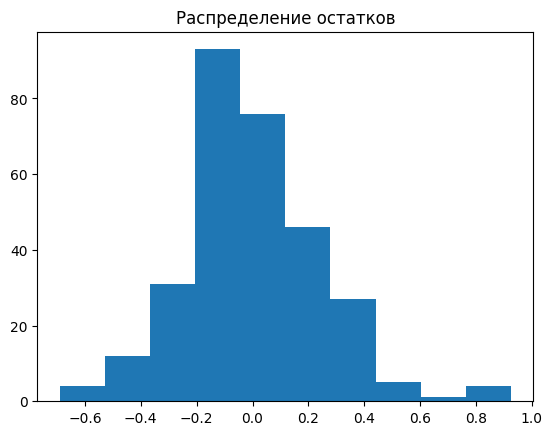

In [ ]:
residuals = model_fitted.resid
print(stats.shapiro(residuals))
plt.hist(residuals)
plt.title("Распределение остатков")
plt.show()

H0: остатки нормальны

H1: остатки не нормальны

p-value < 0.05 , H0 отвергается.

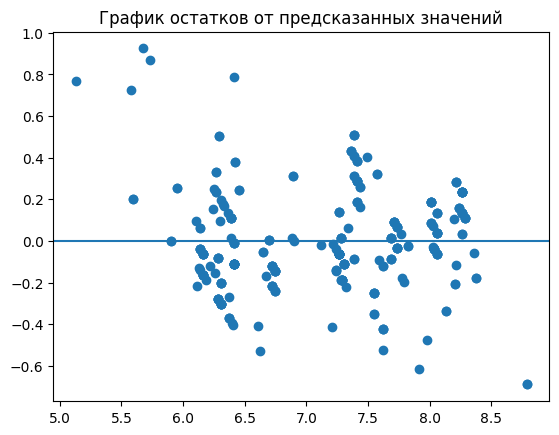

In [ ]:
plt.scatter(model_fitted.fittedvalues, residuals)
plt.title("График остатков от предсказанных значений")
plt.axhline(0)
plt.show()

Можно утверждать, что остатки разбросаны случайно.

#### Проверка значимости коэффициентов:

p-value < 0.05 у таких признаков возраст, категория BMI, расстройство сна, пол, все субъективные и объективные показатели состояния здоровья (уровень стресса, давление и т.д.). Данные признаки значимы в контексте построенной модели.

p-value некоторых профессий (медсестра, учитель, менеджер, ученый) > 0.05, значит данные признаки не значимы.

#### Интерпретация коэффициентов:

Среди значимых признаков наибольшее положительное значение имеют факторы Нижнее давление, Качество сна и пол. Сильнее всего отрицательно связано верхнее давление. Также отрицательную связь имеет количество пройденных за день шагов -- чем больше шагов, тем меньше будет длиться сон.

#### Проверка на тестовой выборке

Text(0.5, 1.0, 'Результаты прогноза по тестовой выборке')

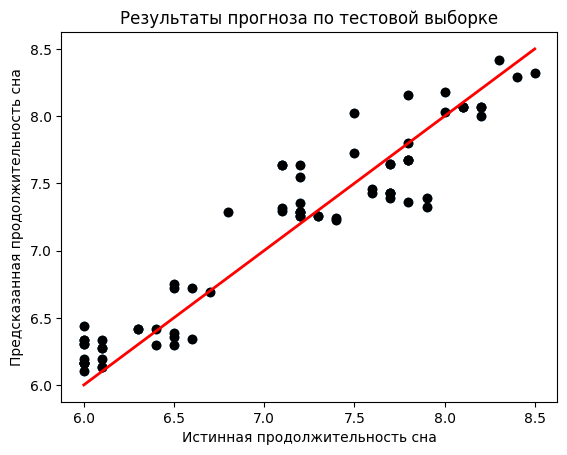

In [ ]:
X_test_with_const = sm.add_constant(X_test)
y_pred = model_fitted.predict(X_test_with_const)
plt.scatter(y_test, y_pred)

mn = min(y_test.min(), y_pred.min())
mx = max(y_test.max(), y_pred.max())
plt.scatter(y_test, y_pred, c="black")
plt.plot([mn, mx], [mn, mx], c="red", lw="2.")
plt.xlabel("Истинная продолжительность сна")
plt.ylabel("Предсказанная продолжительность сна")
plt.title("Результаты прогноза по тестовой выборке")

### Проверка мультиколлинеарности

Корреляционная матрица признаков

<Axes: >

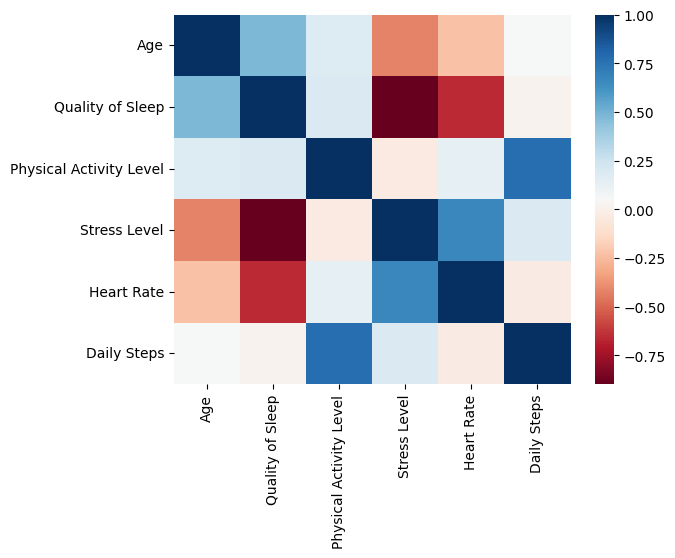

In [ ]:
sns.heatmap(data[data.select_dtypes("number").columns.drop("Sleep Duration")].corr(), cmap="RdBu")

In [24]:
corr = data[data.select_dtypes("number").columns.drop("Sleep Duration")].corr()

corr_pairs = corr.unstack().sort_values(ascending=False)

top_corr = corr_pairs[corr_pairs < 1].drop_duplicates()

print(top_corr.head(5))
print()
print(top_corr.tail(5))

Physical Activity Level  Daily Steps                0.772723
Stress Level             Heart Rate                 0.670026
Age                      Quality of Sleep           0.473734
Quality of Sleep         Physical Activity Level    0.192896
Stress Level             Daily Steps                0.186829
dtype: float64

Stress Level      Physical Activity Level   -0.034134
Heart Rate        Age                       -0.225606
Age               Stress Level              -0.422344
Quality of Sleep  Heart Rate                -0.659865
Stress Level      Quality of Sleep          -0.898752
dtype: float64


Высокую корреляцию имеет достаточно большое количество признаков:

Положительно коррелируют уровень физической активности с количеством шагов за день (0.77); уровень стресса и чсс (0.67).

Отрицательно коррелируют качество сна и уровень стресса (-0.89); качество сна и чсс (-0.65).

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df_transformed[data.select_dtypes("number").columns]

X['const'] = 1

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data[vif_data['feature'] != 'const'].sort_values("VIF", ascending=False))

                   feature        VIF
2         Quality of Sleep  11.000056
4             Stress Level   7.952974
1           Sleep Duration   5.295312
6              Daily Steps   5.069089
3  Physical Activity Level   5.007188
5               Heart Rate   3.420481
0                      Age   1.385041


Мультиколлениарность по фактору "Качество сна" есть (VIF = 11)

### Ridge-регрессия

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

alphas = np.linspace(0.25, 50, 200)
ridge_params = {'alpha': alphas}

ridge_grid = GridSearchCV(Ridge(), cv=4, param_grid=ridge_params, scoring="neg_mean_squared_error")
ridge_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': array([ 0.25,...49.75, 50. ])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candi

Text(0.5, 1.0, 'Зависимость MSE от альфа')

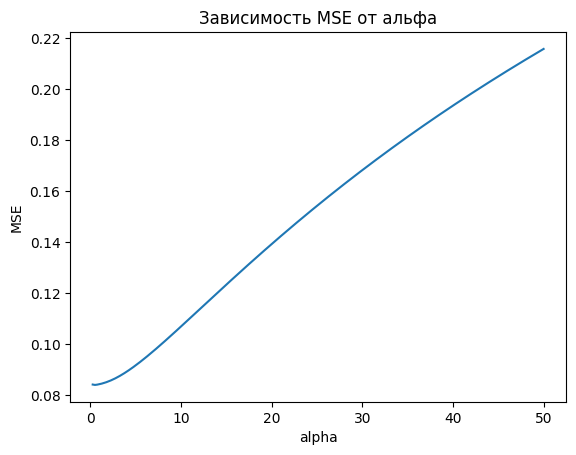

In [ ]:
results_df = pd.DataFrame(ridge_grid.cv_results_)

history = results_df[['param_alpha', 'mean_test_score']].copy()
history['MSE'] = -history['mean_test_score']
history = history.sort_values('param_alpha')

plt.plot(history["param_alpha"], history["MSE"])
plt.xlabel("alpha")
plt.ylabel("MSE")
plt.title("Зависимость MSE от альфа")

In [ ]:
history.sort_values("MSE").iloc[0]

param_alpha        0.500000
mean_test_score   -0.083892
MSE                0.083892
Name: 1, dtype: float64

Минимальная ошибка допускается при $\alpha$ = 1.7587

### LASSO-регрессия

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

lasso_alphas = np.linspace(0.005, 1, 300)
lasso_params = {'alpha': lasso_alphas}

lasso_grid = GridSearchCV(Lasso(), cv=4, param_grid=lasso_params, scoring="neg_mean_squared_error")
lasso_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Lasso()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': array([0.005 ..., 1. ])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate p

Text(0.5, 1.0, 'Зависимость MSE от альфа')

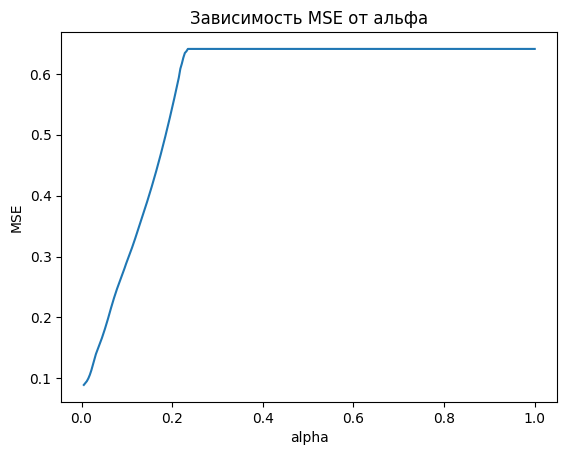

In [ ]:
results_df = pd.DataFrame(lasso_grid.cv_results_)

lasso_history = results_df[['param_alpha', 'mean_test_score']].copy()
lasso_history['MSE'] = -lasso_history['mean_test_score']
lasso_history = lasso_history.sort_values('param_alpha')

plt.plot(lasso_history["param_alpha"].astype(float), lasso_history["MSE"])
plt.xlabel("alpha")
plt.ylabel("MSE")
plt.title("Зависимость MSE от альфа")

In [ ]:
lasso_history.sort_values("MSE").iloc[0]

param_alpha        0.005000
mean_test_score   -0.089246
MSE                0.089246
Name: 0, dtype: float64

Минимальная ошибка допускается при $\alpha$ = 0.025

Сравнение моделей линейной регрессии по MAPE, RMSE, MAE

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, root_mean_squared_error

def evaluate_model(model, name):
    
    if model == model_fitted:
        prediction = model.predict(sm.add_constant(X_test))
    else:
        prediction = model.predict(X_test)
    print(f"""
        {name}
        MAPE: {mean_absolute_percentage_error(y_test, prediction)}
        RMSE: {root_mean_squared_error(y_test, prediction)}
        MAE: {mean_absolute_error(y_test, prediction)}""")

for mod, name in zip([model_fitted, ridge_grid, lasso_grid],
                     ["Обычный МНК", "Ridge", "Lasso"]):
    evaluate_model(mod, name)



        Обычный МНК
        MAPE: 0.027758778591042053
        RMSE: 0.24064327952597647
        MAE: 0.19409531904372007

        Ridge
        MAPE: 0.028791102680467747
        RMSE: 0.2420688559436111
        MAE: 0.20009645674780918

        Lasso
        MAPE: 0.034213852952878605
        RMSE: 0.27945207900933733
        MAE: 0.23787914138076796


 Наилучшие результаты по всем метрикам показала обычная МНК-регрессия без регуляризации.

 Метрики Lasso-регрессии хуже, чем Ridge, но все модели все равно достаточно точно предсказывают продолжительность сна -- ошибки не превышают 16 минут.

### Вывод:
Качество подгонки уравнения хорошее, линейная связь между признаками и целевой переменной присутствует, большинстов коэффициентов регрессии значимо. В остатках присутствует автокорреляция, остатки имеют случайный характер и распределены не нормально. Их дисперсия гетероскедастичная, мат. ожидание равно нулю.